# Preprocessing

In [58]:
import os
import pandas as pd

# Load the data
df_churn = pd.read_csv("patient_churn_dataset.csv")

df_churn.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [59]:
# Show percentage of null values per column
null_percent = (df_churn.isnull().sum() / len(df_churn)) * 100
print(null_percent)

PatientID                     0.0
Age                           0.0
Gender                        0.0
State                         0.0
Tenure_Months                 0.0
Specialty                     0.0
Insurance_Type                0.0
Visits_Last_Year              0.0
Missed_Appointments           0.0
Days_Since_Last_Visit         0.0
Last_Interaction_Date         0.0
Overall_Satisfaction          0.0
Wait_Time_Satisfaction        0.0
Staff_Satisfaction            0.0
Provider_Rating               0.0
Avg_Out_Of_Pocket_Cost        0.0
Billing_Issues                0.0
Portal_Usage                  0.0
Referrals_Made                0.0
Distance_To_Facility_Miles    0.0
Churned                       0.0
dtype: float64


/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_23878/1304318499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df_churn, palette=['#2ECC71', '#C8E6C9'])


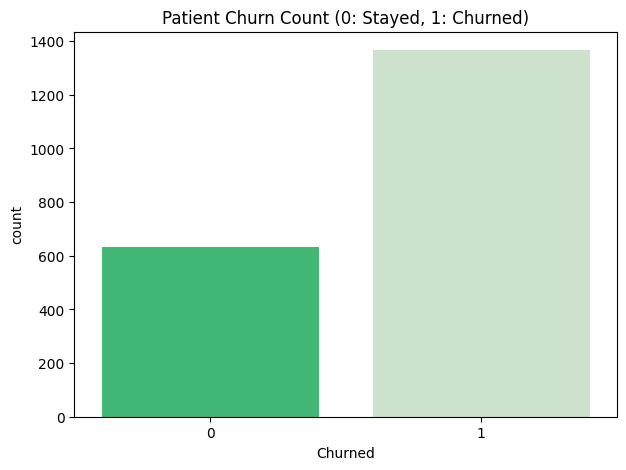

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Churned', data=df_churn, palette=['#2ECC71', '#C8E6C9'])
plt.title('Patient Churn Count (0: Stayed, 1: Churned)', color='black')
plt.show()

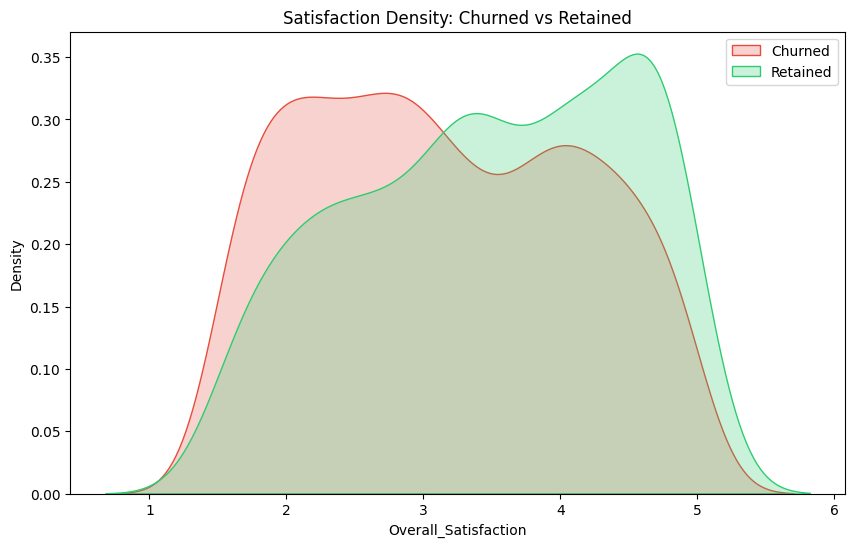

In [61]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_churn[df_churn['Churned'] == 1]['Overall_Satisfaction'], label='Churned', fill=True, color='#E74C3C')
sns.kdeplot(df_churn[df_churn['Churned'] == 0]['Overall_Satisfaction'], label='Retained', fill=True, color='#2ECC71')
plt.title('Satisfaction Density: Churned vs Retained', color='black')
plt.legend()
plt.show()

/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_23878/526594683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Avg_Out_Of_Pocket_Cost', data=df_churn, palette='Greens')


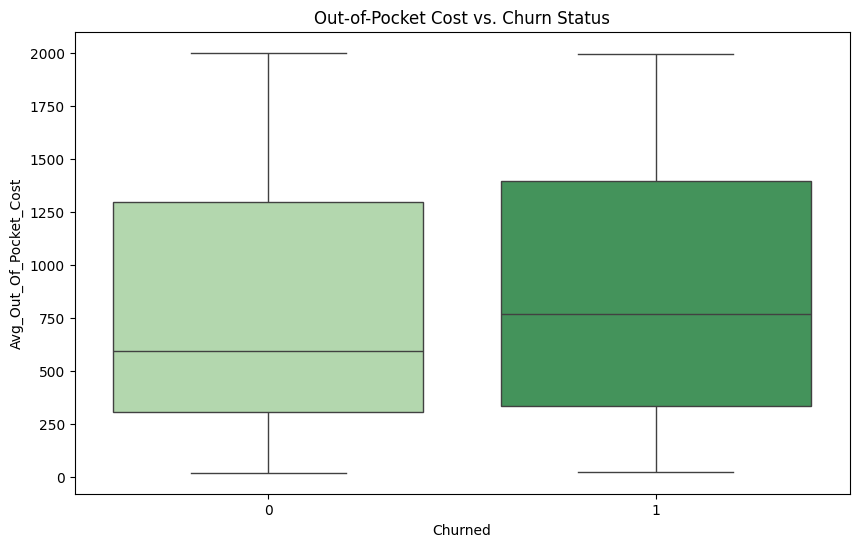

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churned', y='Avg_Out_Of_Pocket_Cost', data=df_churn, palette='Greens')
plt.title('Out-of-Pocket Cost vs. Churn Status', color='black')
plt.show()

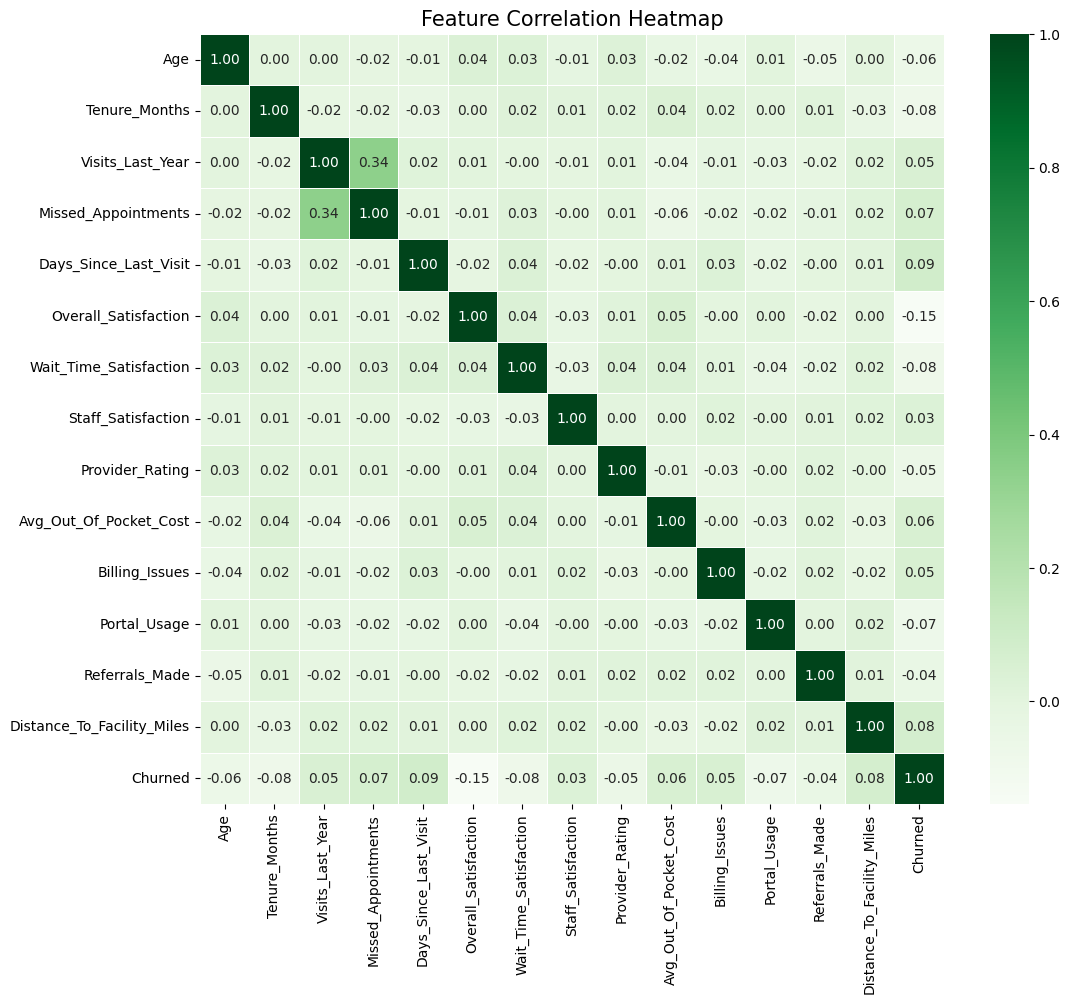

In [63]:
import numpy as np

plt.figure(figsize=(12, 10))
corr = df_churn.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Feature Correlation Heatmap', color='black', fontsize=15)
plt.show()

In [64]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features_to_scale = df_churn.select_dtypes(include=['int64', 'float64']).columns.drop('Churned')
df_churn[features_to_scale] = scaler.fit_transform(df_churn[features_to_scale])

In [65]:
unique_values = df_churn['Gender'].unique()
print(unique_values)

unique_values = df_churn['Specialty'].unique()
print(unique_values)

unique_values = df_churn['Insurance_Type'].unique()
print(unique_values)

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
[       'Pediatrics', 'Internal Medicine',  'General Practice',
        'Cardiology',       'Orthopedics',         'Neurology',
   'Family Medicine']
Length: 7, dtype: str
<StringArray>
['Medicaid', 'Self-Pay', 'Private', 'Medicare']
Length: 4, dtype: str


In [66]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(df_churn[['Gender', 'Specialty', 'Insurance_Type']])

# Create a DataFrame with the new column names
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Gender', 'Specialty', 'Insurance_Type']))

# Concatenate with the original dataframe and drop the old categorical columns
df_churn = pd.concat([df_churn.drop(['Gender', 'Specialty', 'Insurance_Type'], axis=1), encoded_df], axis=1)

In [67]:
df_churn.head()

,PatientID,Age,State,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Last_Interaction_Date,Overall_Satisfaction,Wait_Time_Satisfaction,...,Gender_Male,Specialty_Family Medicine,Specialty_General Practice,Specialty_Internal Medicine,Specialty_Neurology,Specialty_Orthopedics,Specialty_Pediatrics,Insurance_Type_Medicare,Insurance_Type_Private,Insurance_Type_Self-Pay
0,C20000,-0.748870,PA,0.036080,-1.415979,-1.193723,0.929678,2024-07-05,0.242973,1.596039,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,C20001,-0.622547,GA,-0.476704,-0.131450,1.160760,-0.526835,2025-05-11,-0.649581,-0.188242,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,C20002,-2.012092,MI,1.688383,1.581255,1.749381,-1.302076,2025-10-23,-1.641307,1.100405,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C20003,0.766997,FL,1.631407,0.510814,0.572139,-1.085948,2025-09-07,-0.649581,1.001279,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,C20004,-2.201575,CA,0.263984,-0.559626,1.160760,1.549871,2024-02-24,-1.046271,0.703899,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
from sklearn.model_selection import train_test_split

# Removing non-predictive IDs and dates before model training.
X = df_churn.drop(['PatientID', 'Last_Interaction_Date', 'Churned', 'State'], axis=1)
y = df_churn['Churned']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(f"Training samples: {X_train.shape[0]}")

Training samples: 1600


## applying SMOTE for class inbalance

<Axes: >

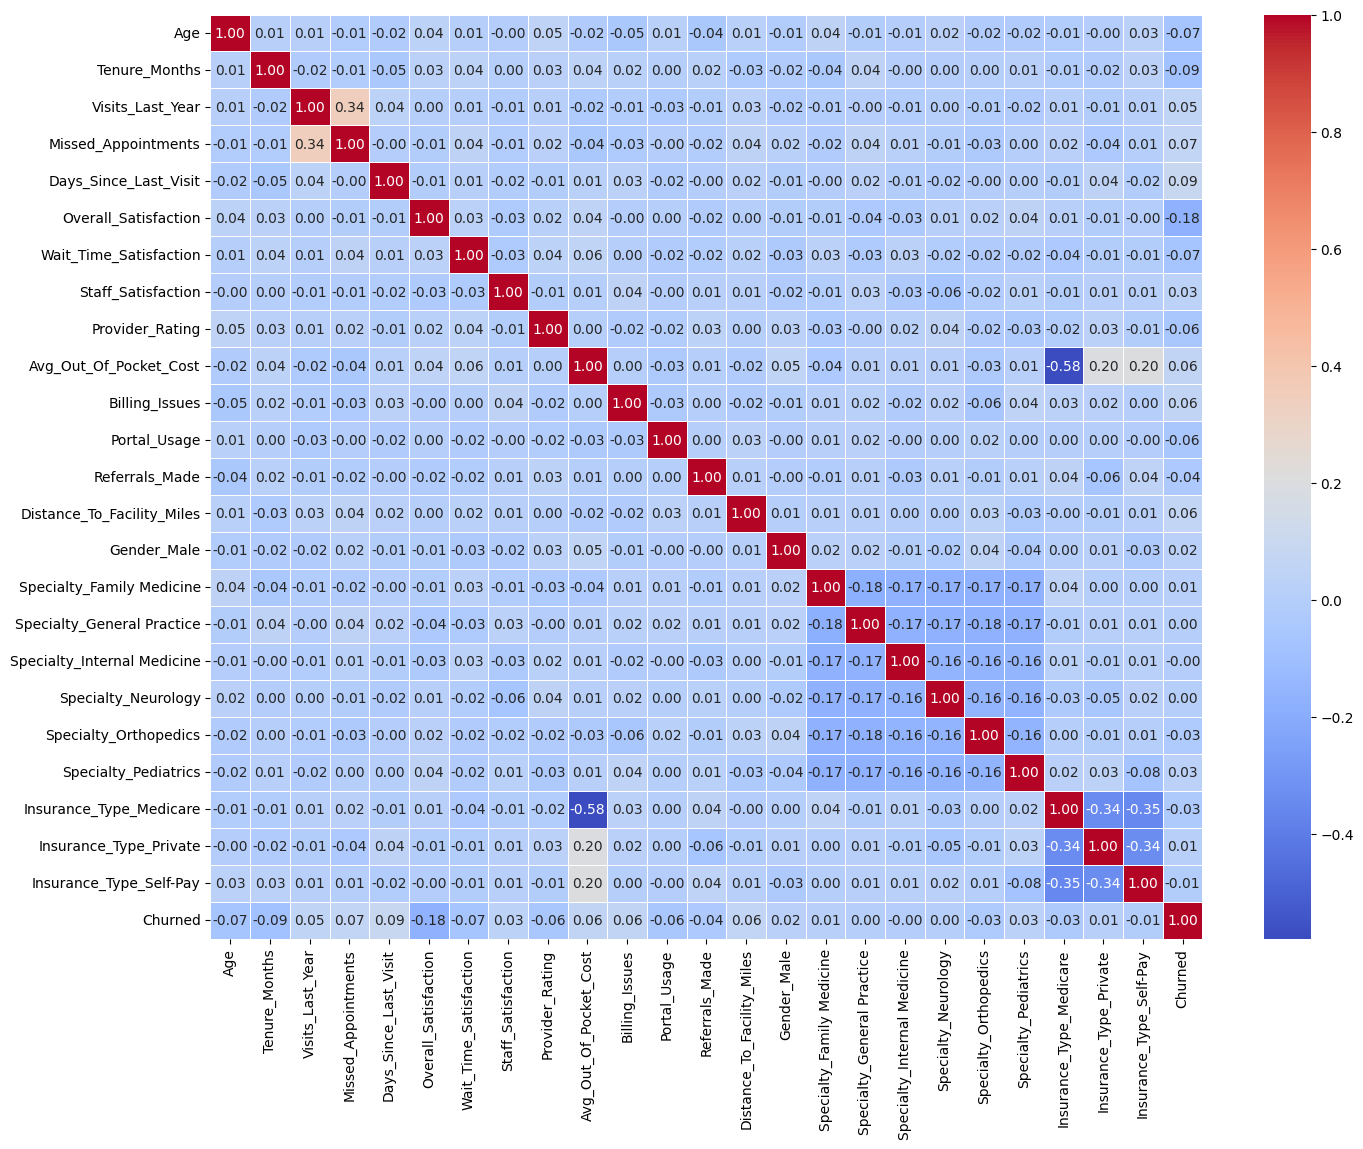

In [70]:
# initial heatmap
corr = pd.concat([X_train, y_train], axis=1).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'Churned Value Counts')

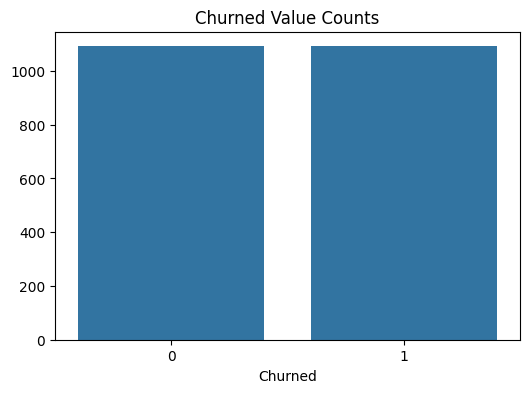

In [72]:
freq = y_res.value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=freq.index, y=freq.values)
plt.title('Churned Value Counts')

<Axes: >

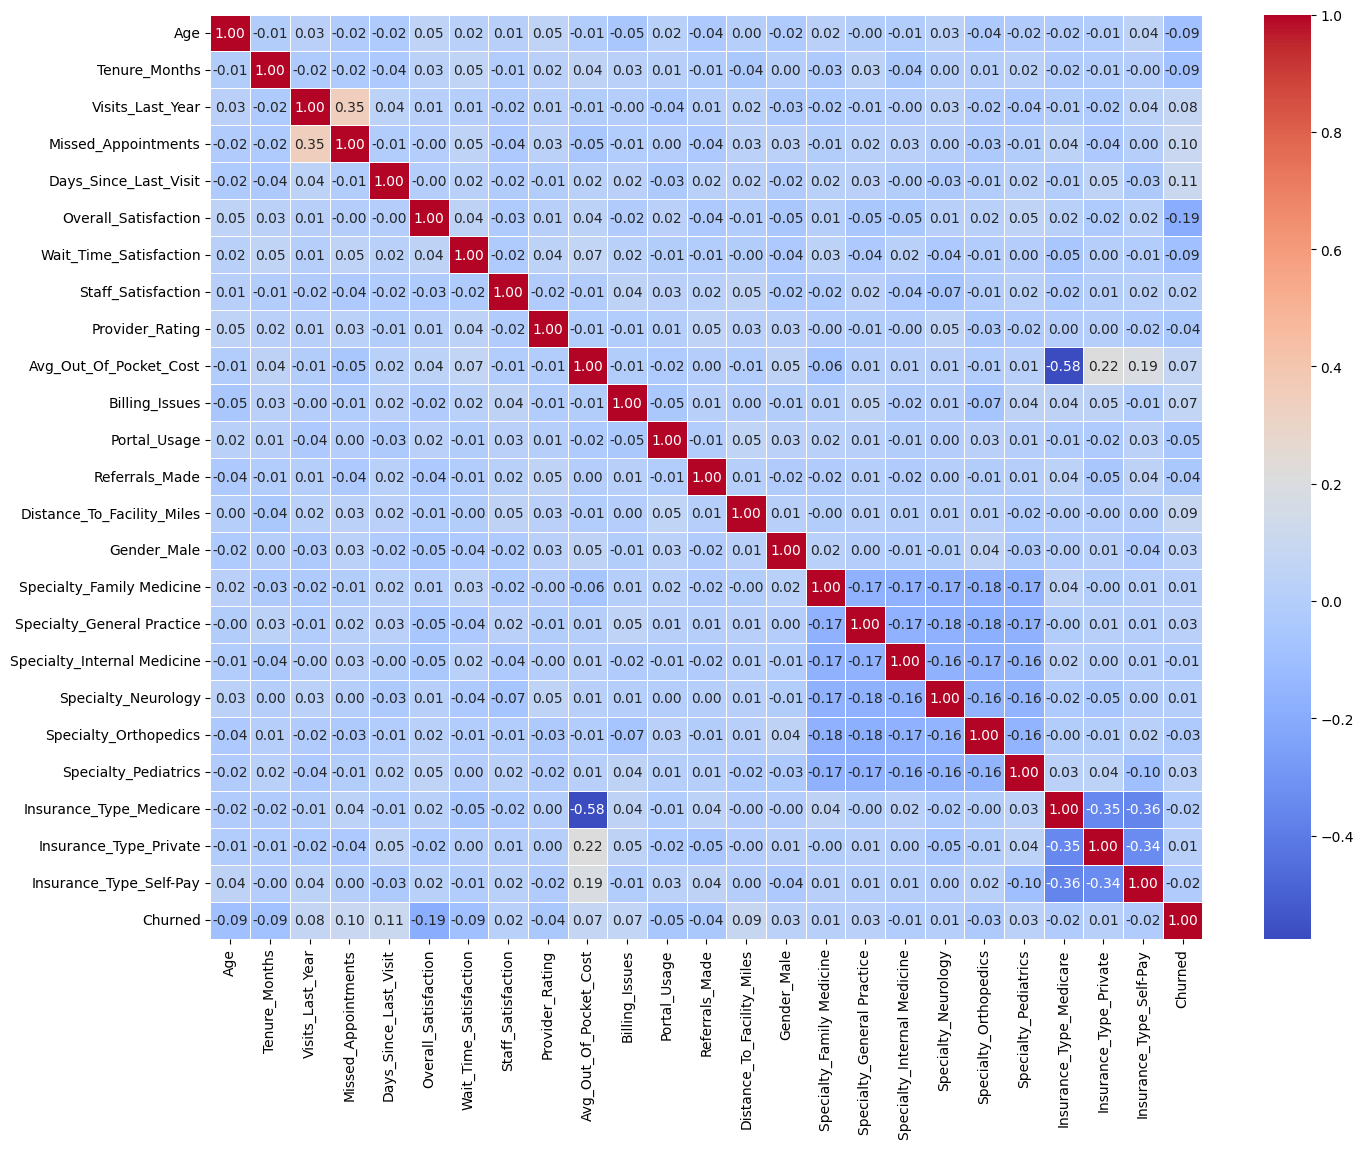

In [73]:
# heatmap after SMOTE

corr = pd.concat([X_res, y_res], axis=1).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

In [74]:
X_train = X_res
y_train = y_res

# Logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

Recall:   0.6232
F1-Score: 0.6894

--- Detailed Report ---
              precision    recall  f1-score   support

           0       0.41      0.59      0.49       124
           1       0.77      0.62      0.69       276

    accuracy                           0.61       400
   macro avg       0.59      0.61      0.59       400
weighted avg       0.66      0.61      0.63       400



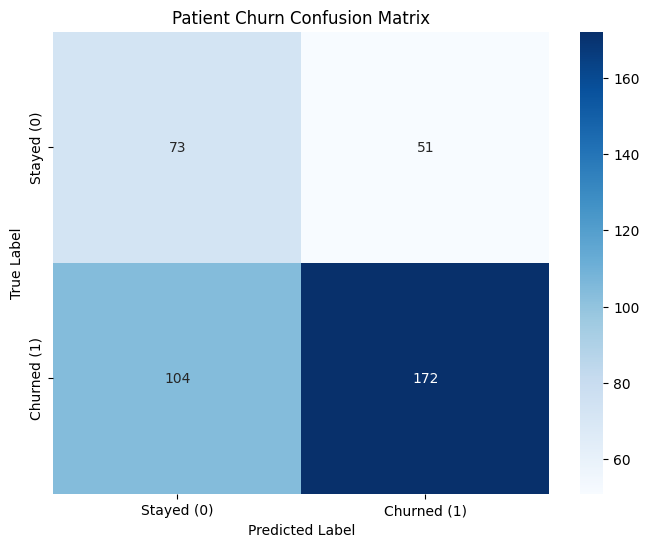

In [76]:
from sklearn.metrics import recall_score, f1_score, classification_report

# 1. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_lg = recall_score(y_test, lr_preds)

# 2. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_lg = f1_score(y_test, lr_preds)

print(f"Recall:   {recall_lg:.4f}")
print(f"F1-Score: {f1_lg:.4f}")

# 3. Optional: Get the full breakdown (includes Precision and Accuracy)
print("\n--- Detailed Report ---")
print(classification_report(y_test, lr_preds))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the matrix
cm = confusion_matrix(y_test, lr_preds)

# 2. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

                        Feature  Importance  Magnitude
5          Overall_Satisfaction   -0.425838   0.425838
20         Specialty_Pediatrics    0.367803   0.367803
15    Specialty_Family Medicine    0.276086   0.276086
9        Avg_Out_Of_Pocket_Cost    0.267190   0.267190
4         Days_Since_Last_Visit    0.219840   0.219840
6        Wait_Time_Satisfaction   -0.209643   0.209643
18          Specialty_Neurology    0.207655   0.207655
16   Specialty_General Practice    0.204050   0.204050
3           Missed_Appointments    0.197464   0.197464
0                           Age   -0.179973   0.179973
13   Distance_To_Facility_Miles    0.176434   0.176434
1                 Tenure_Months   -0.164934   0.164934
22       Insurance_Type_Private   -0.159062   0.159062
23      Insurance_Type_Self-Pay   -0.144689   0.144689
10               Billing_Issues    0.135122   0.135122
12               Referrals_Made   -0.126413   0.126413
21      Insurance_Type_Medicare    0.116437   0.116437
2         

/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_23878/4252111544.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


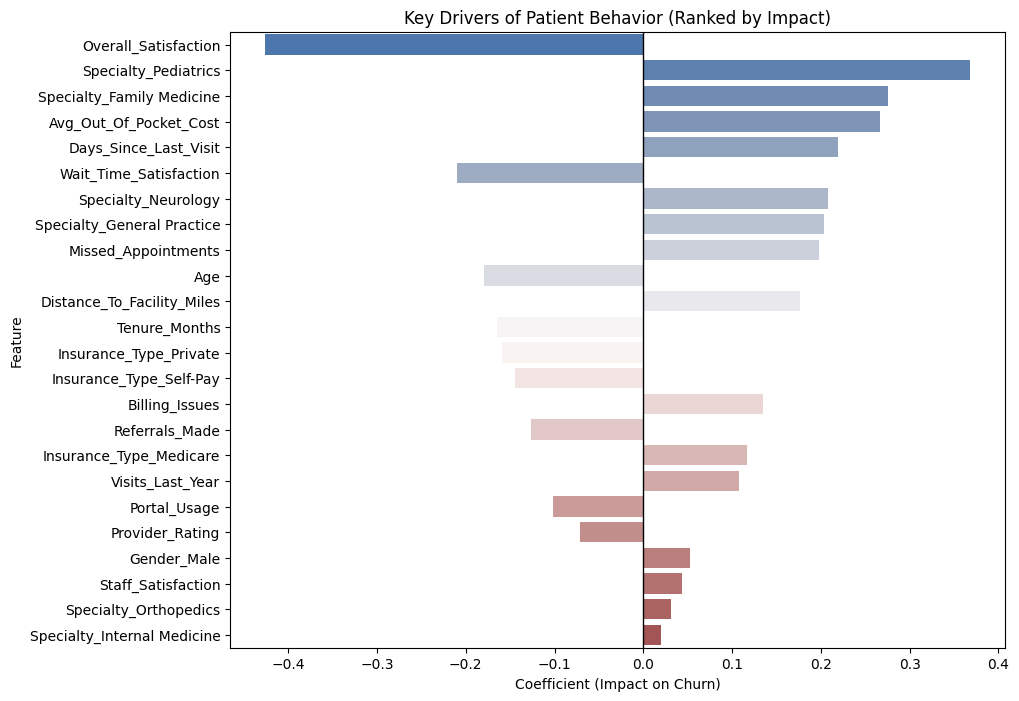

In [77]:
# Create a DataFrame of features and their corresponding coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lr_model.coef_[0]
})

# 1. Add a magnitude column
feature_importance['Magnitude'] = feature_importance['Importance'].abs()

# 2. Sort by Magnitude (highest to lowest)
feature_importance = feature_importance.sort_values(by='Magnitude', ascending=False)

print(feature_importance[['Feature', 'Importance', 'Magnitude']])

plt.figure(figsize=(10, 8))
# We sort the dataframe by 'Magnitude' before plotting
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance.sort_values(by='Magnitude', ascending=False),
    palette='vlag' # Useful for showing divergent (pos/neg) values
)

plt.title('Key Drivers of Patient Behavior (Ranked by Impact)')
plt.xlabel('Coefficient (Impact on Churn)')
plt.axvline(x=0, color='black', lw=1)
plt.show()

# Decision Tree

Recall:   0.6812
F1-Score: 0.6989
Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.36      0.40      0.38       124
           1       0.72      0.68      0.70       276

    accuracy                           0.59       400
   macro avg       0.54      0.54      0.54       400
weighted avg       0.61      0.59      0.60       400



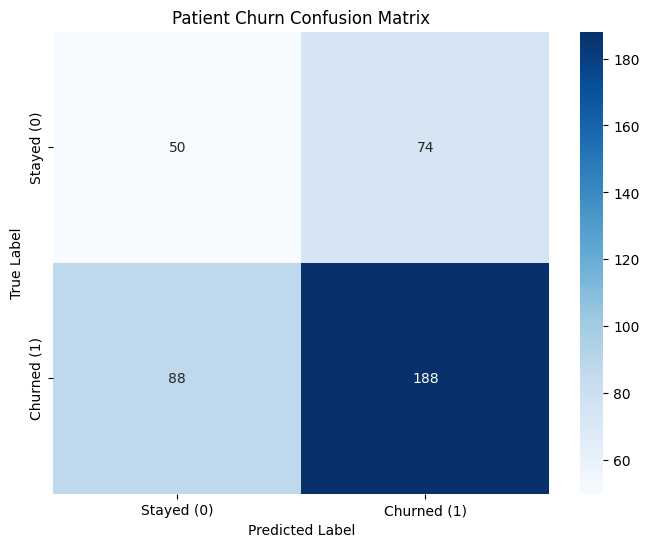

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
# We set max_depth to prevent the tree from growing infinitely (overfitting)

# dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=2)

# 2. Fit the model
dt_model.fit(X_train, y_train)

# 3. Make predictions
dt_preds = dt_model.predict(X_test)

# 4. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_dt = recall_score(y_test, dt_preds)

# 5. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_dt = f1_score(y_test, dt_preds)

print(f"Recall:   {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# 6. Evaluate
print("Decision Tree Performance:")
print(classification_report(y_test, dt_preds))

# 7. Generate the matrix
cm = confusion_matrix(y_test, dt_preds)

# 8. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

                        Feature  Importance
3           Missed_Appointments    0.280643
14                  Gender_Male    0.226272
5          Overall_Satisfaction    0.124327
12               Referrals_Made    0.066520
4         Days_Since_Last_Visit    0.061718
1                 Tenure_Months    0.056856
20         Specialty_Pediatrics    0.039029
0                           Age    0.036543
2              Visits_Last_Year    0.026751
11                 Portal_Usage    0.026727
9        Avg_Out_Of_Pocket_Cost    0.023417
8               Provider_Rating    0.020356
6        Wait_Time_Satisfaction    0.010841
10               Billing_Issues    0.000000
7            Staff_Satisfaction    0.000000
13   Distance_To_Facility_Miles    0.000000
15    Specialty_Family Medicine    0.000000
16   Specialty_General Practice    0.000000
17  Specialty_Internal Medicine    0.000000
18          Specialty_Neurology    0.000000
19        Specialty_Orthopedics    0.000000
21      Insurance_Type_Medicare 

/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_23878/369430910.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_analysis, palette='viridis')


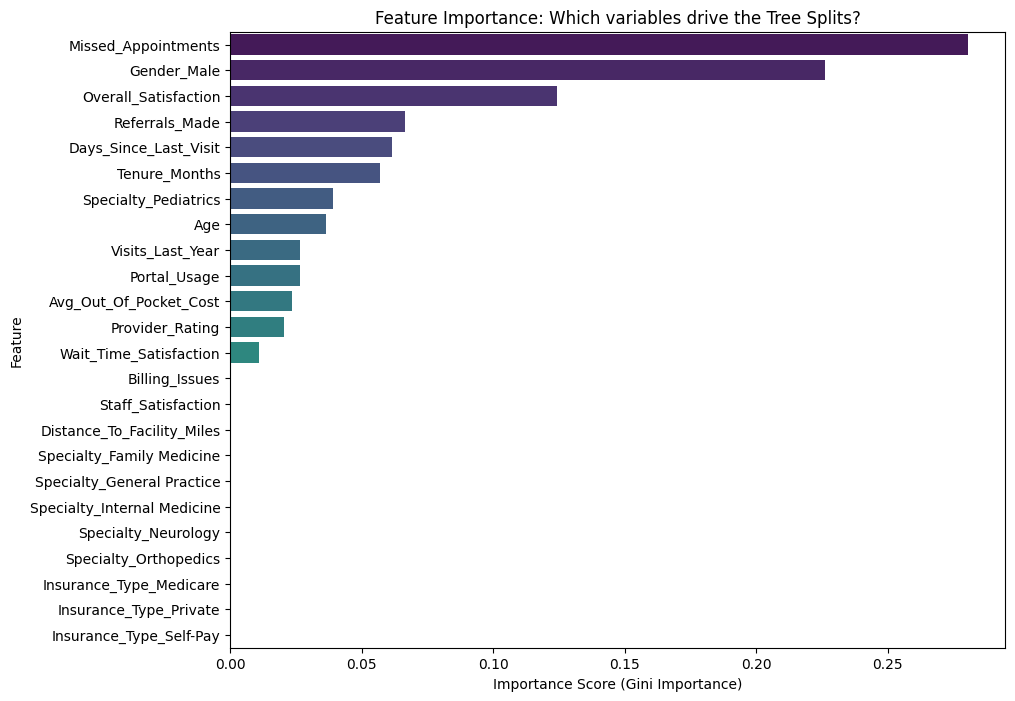

In [79]:
# 1. Get the importance scores
importances = dt_model.feature_importances_

# 2. Create a DataFrame
feature_analysis = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_analysis)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_analysis, palette='viridis')
plt.title('Feature Importance: Which variables drive the Tree Splits?')
plt.xlabel('Importance Score (Gini Importance)')
plt.show()

# random forest

Recall:   0.8696
F1-Score: 0.7934
              precision    recall  f1-score   support

           0       0.49      0.28      0.36       124
           1       0.73      0.87      0.79       276

    accuracy                           0.69       400
   macro avg       0.61      0.58      0.58       400
weighted avg       0.66      0.69      0.66       400



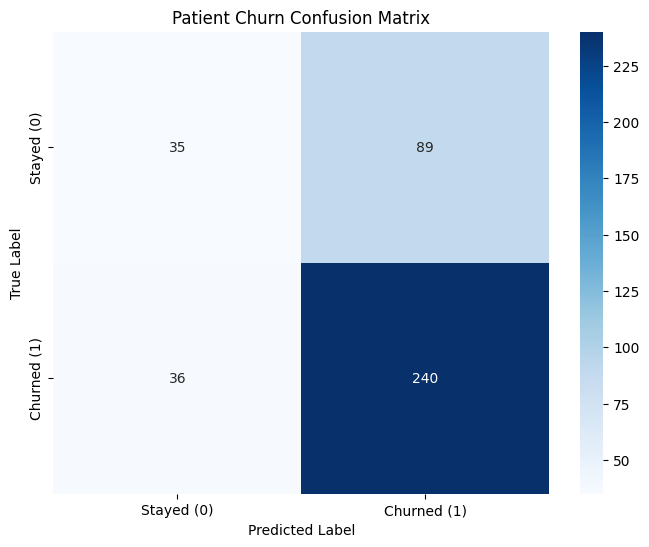

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 1. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_rf = recall_score(y_test, y_pred_rf)

# 2. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Recall:   {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print(classification_report(y_test, y_pred_rf))

# 3. Generate the matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 4. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_23878/975623345.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_analysis, palette='magma')


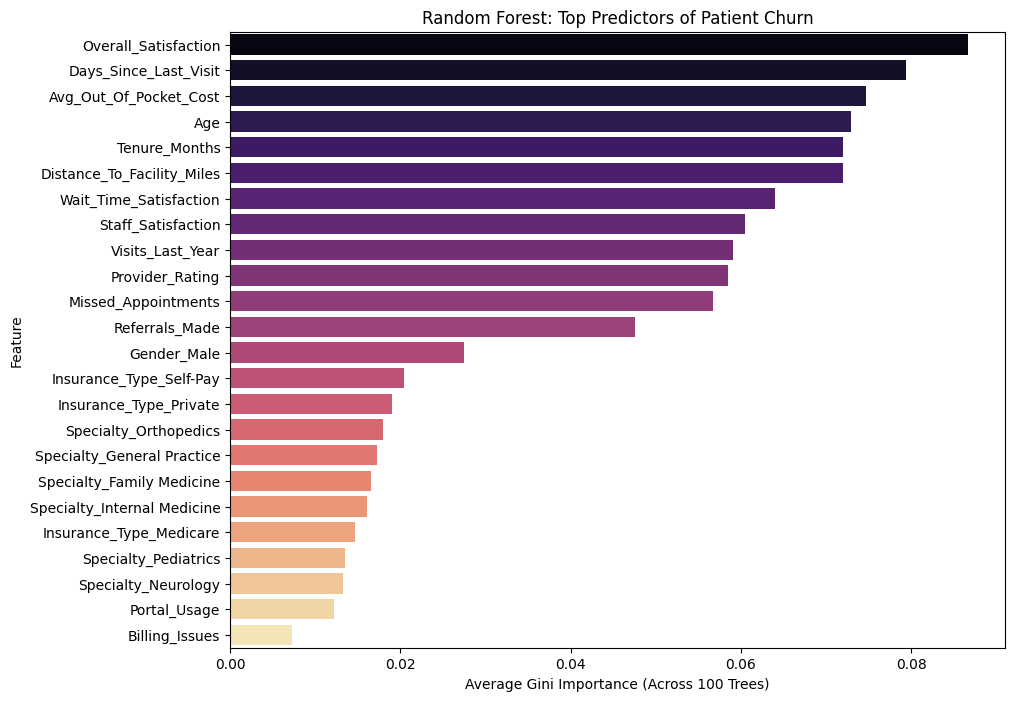

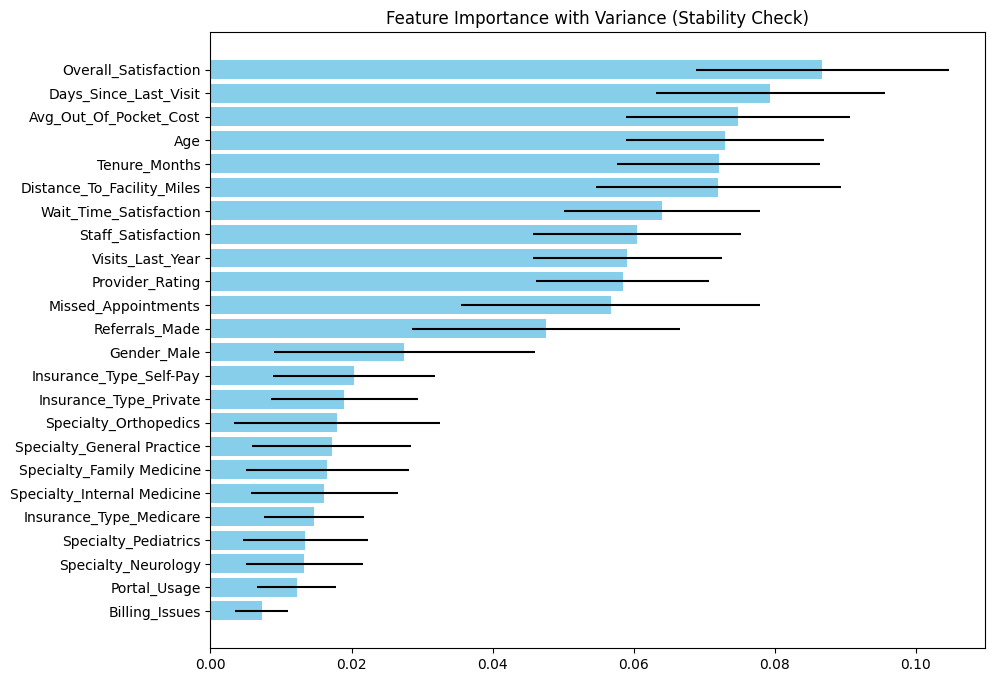

In [81]:
# 1. Get the average importance from all 100 trees
rf_importances = rf_model.feature_importances_

# 2. Create a DataFrame for ranking
rf_analysis = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualize
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_analysis, palette='magma')
plt.title('Random Forest: Top Predictors of Patient Churn')
plt.xlabel('Average Gini Importance (Across 100 Trees)')
plt.show()

# Calculate standard deviation of importance across all trees
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

# Add to your dataframe
rf_analysis['Std_Dev'] = std[rf_analysis.index] # Match indices

# Plot with error bars
plt.figure(figsize=(10, 8))
plt.barh(rf_analysis['Feature'], rf_analysis['Importance'], xerr=rf_analysis['Std_Dev'], color='skyblue')
plt.gca().invert_yaxis() # Highest importance at the top
plt.title('Feature Importance with Variance (Stability Check)')
plt.show()

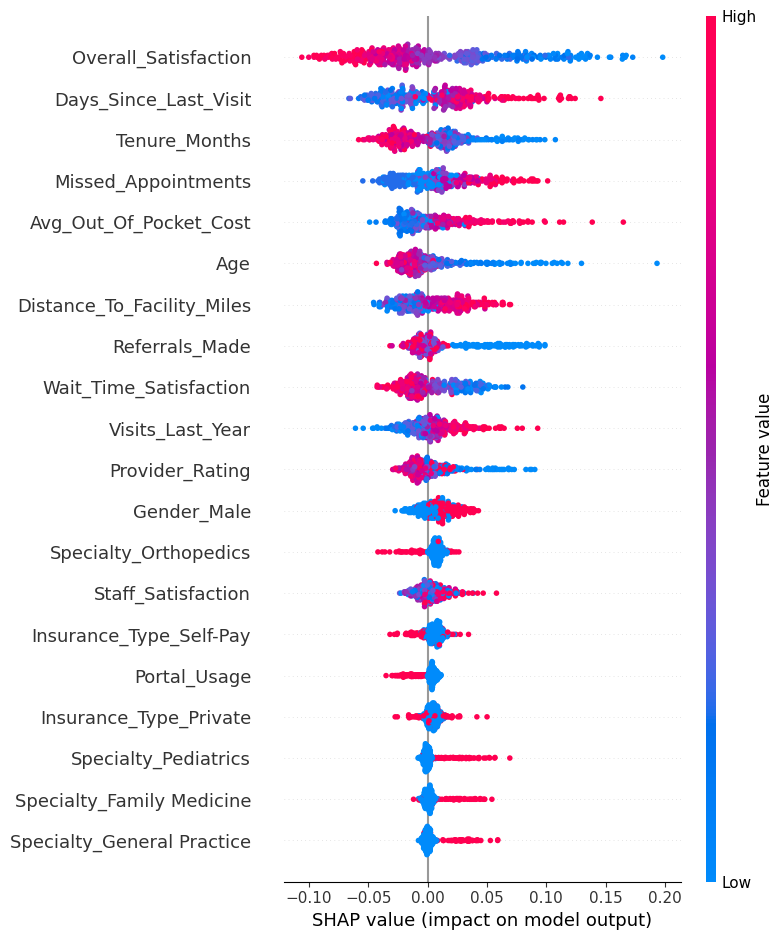

In [85]:
import shap

# 1. Create the explainer
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for your test set
# This might take a minute depending on your data size
shap_values = explainer.shap_values(X_test)

# 3. Visualize the Summary Plot
# For binary classification, shap_values[1] usually represents the "Churn" class
shap.summary_plot(shap_values[:, :, 1], X_test)



# KNN

Recall:   0.4601
F1-Score: 0.5747
KNN Model Performance:
              precision    recall  f1-score   support

           0       0.36      0.69      0.47       124
           1       0.77      0.46      0.57       276

    accuracy                           0.53       400
   macro avg       0.56      0.57      0.52       400
weighted avg       0.64      0.53      0.54       400



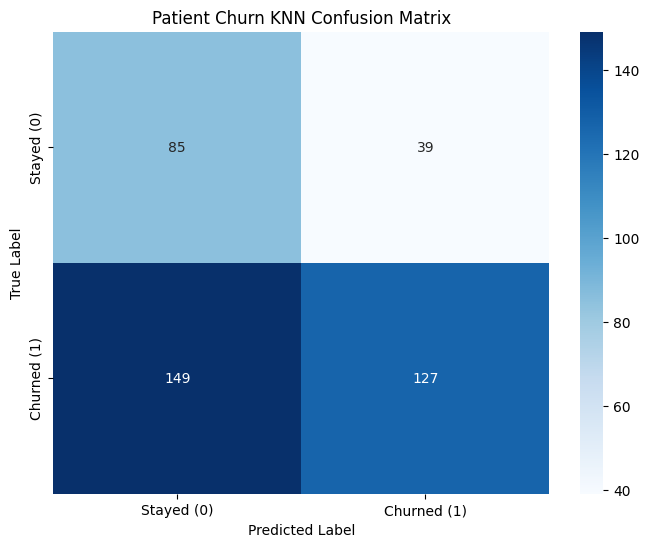

In [47]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')

# 2. Fit the model
knn_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_knn = knn_model.predict(X_test)

# 4. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_knn = recall_score(y_test, y_pred_knn)

# 5. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Recall:   {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

# 6. Evaluation Report
print("KNN Model Performance:")
print(classification_report(y_test, y_pred_knn))

# 7. Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn KNN Confusion Matrix')
plt.show()

# comparing models

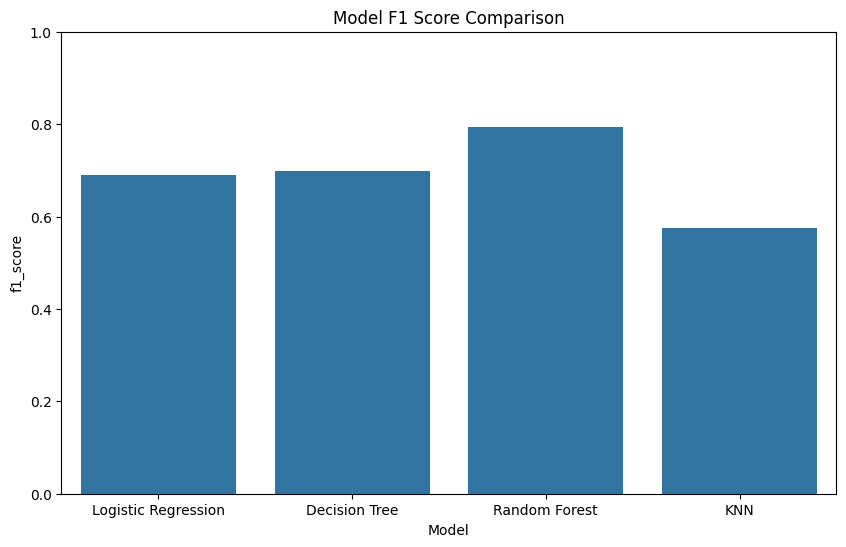

In [48]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'f1_score': [ f1_lg, f1_dt, f1_rf, f1_knn ]  })
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='f1_score', data=models_comparison)
plt.ylim(0, 1)
plt.title('Model F1 Score Comparison')
plt.show()

In [49]:
models_comparison.sort_values(by='f1_score', ascending=False)

,Model,f1_score
2,Random Forest,0.793388
1,Decision Tree,0.698885
0,Logistic Regression,0.689379
3,KNN,0.574661


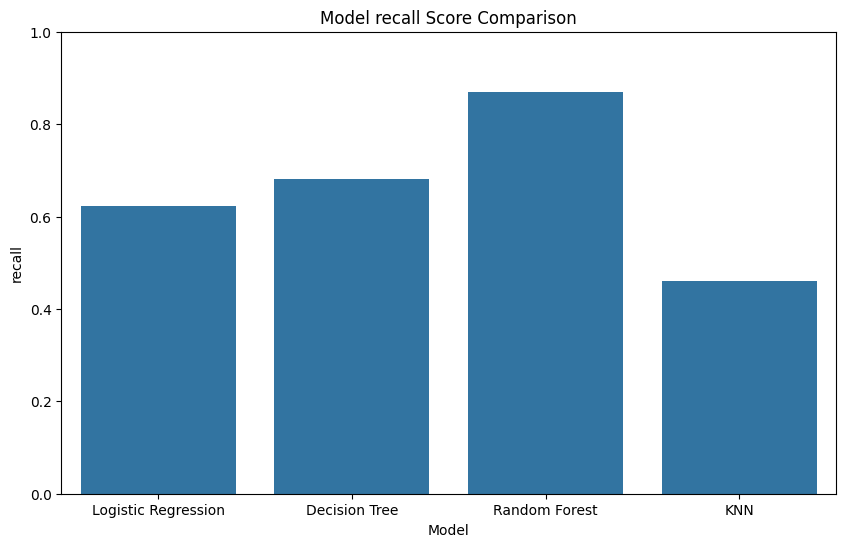

In [50]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'recall': [ recall_lg, recall_dt, recall_rf, recall_knn ]  })
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='recall', data=models_comparison)
plt.ylim(0, 1)
plt.title('Model recall Score Comparison')
plt.show()

In [51]:
models_comparison.sort_values(by='recall', ascending=False)

,Model,recall
2,Random Forest,0.869565
1,Decision Tree,0.681159
0,Logistic Regression,0.623188
3,KNN,0.460145
